<a href="https://colab.research.google.com/github/Hawlll/Hancoded_MLAlgos/blob/main/NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import numpy as np
import tensorflow.keras as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

from tqdm import tqdm

In [50]:
class InitStrategy:

  def __init__(self, init_func, name=""):

    self.init_func = init_func
    self.name = name

  def apply(self, num_units, input_dim=None, num_matrices=1):

    if input_dim:

      return self.init_func(num_units, input_dim, num_matrices)

    return self.init_func(num_units)

class LearningOptimizer:

  def __init__(self, lr=0.1, name="Generic Learning Opt"):

    self.lr = lr
    self.name = name

  def get_grads(self, gradients, ind, epoch):

    updates = []

    for i in range(len(gradients[ind])):

      updates.append(-self.lr*gradients[ind][i])

    return updates

class DecayLearningOptimizer(LearningOptimizer):

  def __init__(self, lr=1, decay=0.95, name="Decay"):

    super().__init__(lr, name)

    self.decay = decay
    self.epoch = None

  def get_grads(self, gradients, ind, epoch):

    if not self.epoch:

      self.epoch = epoch

    elif self.epoch != epoch:

      self.epoch = epoch

      self.lr *= self.decay

    updates = []

    for i in range(len(gradients[ind])):

      updates.append(-self.lr*gradients[ind][i])

    return updates

class MomentumLearningOptimizer(LearningOptimizer):

  def __init__(self, lr=0.1, p=0.9, name="Momentum"):

    super().__init__(lr, name)

    self.p = p
    self.past_grads = []

  def get_grads(self, gradients, ind, epoch):

    if self.past_grads == []:

      for grad in gradients:

        if grad:

          self.past_grads.append([np.zeros_like(g_i) for g_i in grad])

        else:

          self.past_grads.append(None)

    updates = []

    for i in range(len(self.past_grads[ind])):

      prev_grad = self.past_grads[ind][i]

      curr_grad = gradients[ind][i]

      new_grad = self.p*prev_grad - self.lr*curr_grad

      self.past_grads[ind][i] = new_grad

      updates.append(-new_grad)

    return updates

class AdaGradLearningOptimizer(LearningOptimizer):

  def __init__(self, lr=1, name="AdaGrad"):

    super().__init__(lr, name)

    self.past_grads = []

  def get_grads(self, gradients, ind, epoch):

    if self.past_grads == []:

      for grad in gradients:

        if grad:

          self.past_grads.append([np.zeros_like(g_i) for g_i in grad])

        else:

          self.past_grads.append(None)


    updates = []

    for i in range(len(self.past_grads[ind])):

      prev_grad = self.past_grads[ind][i]

      curr_grad = gradients[ind][i]

      r_grad = prev_grad + curr_grad**2

      new_grad = (self.lr / np.sqrt(r_grad + 1e-15)) * curr_grad

      self.past_grads[ind][i] = r_grad

      updates.append(-new_grad)

    return updates


class RMSPropLearningOptimizer(LearningOptimizer):

  def __init__(self, lr=1, beta=0.9, name="RMSProp"):

    super().__init__(lr, name)

    self.beta = beta
    self.past_grads = []

  def get_grads(self, gradients, ind, epoch):

    if self.past_grads == []:

      for grad in gradients:

        if grad:

          self.past_grads.append([np.zeros_like(g_i) for g_i in grad])

        else:

          self.past_grads.append(None)

    updates = []

    for i in range(len(self.past_grads[ind])):

      prev_grad = self.past_grads[ind][i]

      curr_grad = gradients[ind][i]

      r_grad = self.beta * prev_grad + (1 - self.beta) * curr_grad**2

      new_grad = (self.lr / np.sqrt(r_grad + 1e-15)) * curr_grad

      self.past_grads[ind][i] = r_grad

      updates.append(-new_grad)

    return updates

class AdamLearningOptimizer(LearningOptimizer):

  def __init__(self, beta1=0.9, beta2=0.999, lr=1, name="Adam"):

    super().__init__(lr, name)
    self.beta1 = beta1
    self.beta2 = beta2

    self.past_grads = []
    self.velocities = []

  def get_grads(self, gradients, ind, epoch):

    if self.past_grads == []:

      for grad in gradients:

        if grad:

          self.past_grads.append([np.zeros_like(g_i) for g_i in grad])
          self.velocities.append([np.zeros_like(g_i) for g_i in grad])

        else:

          self.past_grads.append(None)
          self.velocities.append(None)

    updates = []

    for i in range(len(self.past_grads[ind])):

      prev_grad = self.past_grads[ind][i]

      curr_grad = gradients[ind][i]

      new_vel = self.beta1 * self.velocities[ind][i] + (1 - self.beta1) * curr_grad

      r_grad = self.beta2 * prev_grad + (1 - self.beta2) * (curr_grad**2)

      self.velocities[ind][i] = new_vel
      self.past_grads[ind][i] = r_grad

      #bias correction

      new_vel = new_vel / (1 - self.beta1**(epoch+1))

      r_grad = r_grad / (1 - self.beta2**(epoch+1))

      updates.append(-(self.lr / np.sqrt(r_grad + 1e-15)) * new_vel)

    return updates

class ActivationFunction:

  def __init__(self, func, deriv_func=None, name=""):

    self.func = func
    self.deriv_func = deriv_func
    self.name = name

  def apply(self, X):

    return self.func(X)

  def apply_deriv(self, X):

    return self.deriv_func(X)

class EvaluationFunction:

  def __init__(self, func, deriv_func=None, name=""):

    self.func = func
    self.deriv_func = deriv_func
    self.name = name

  def apply(self, y_true, y_hat):

    return self.func(y_true, y_hat)

  def apply_deriv(self, y_true, y_hat):

    return self.deriv_func(y_true, y_hat)

class Layer:

  def __init__(self, is_output=False, is_trainable=True, name="Generic_Layer", skip_after_train=False):

    self.is_output = is_output
    self.is_trainable = is_trainable
    self.name = name
    self.skip_after_train = skip_after_train

  def feed(self, inputs, is_training=True):

    pass

  def get_info(self):

    return f"Name: {self.name}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"

class DenseLayer(Layer): # need to implement adding raw input for residual connections when input dim the same as layer dim

  def __init__(self, num_units, activation_func=None, is_output=False, is_trainable=True, init_strat=None, resid_conn=False):
    super().__init__(is_output, is_trainable, "Dense_Layer", False)

    self.num_units = num_units
    self.activation_func = activation_func
    self.init_strat = init_strat
    self.resid_conn = resid_conn
    self.trainable_params = []

    self.W = None
    self.b = None
    self.W_proj = None

  def feed(self, inputs, is_training=True):

    linear_output = (self.W @ inputs) + self.b

    if self.resid_conn:

      linear_output += self.W_proj @ inputs

    activated_output = linear_output

    if self.activation_func:

      activated_output = self.activation_func.apply(linear_output)

    return [linear_output, activated_output]


  def init_params(self, input_dim):

    out = self.init_strat.apply(self.num_units, input_dim, 1+int(self.resid_conn))

    self.W, self.b = out[0], out[-1]
    self.trainable_params = out

    if len(out) > 2 and self.resid_conn:

      self.W_proj = out[1]


  def get_info(self):

    return f"Name: {self.name}\n  Num Units: {self.num_units}\n  Residual Connections Enabled: {self.resid_conn}\n  Activation: {self.activation_func.name if self.activation_func else None}\n  Parameter Init: {self.init_strat.name if self.init_strat else None}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"

class DropoutLayer(Layer):

  def __init__(self, drop_rate=0.3, scale=True):

    super().__init__(True, False, "Dropout_Layer", True)
    self.drop_rate = drop_rate
    self.scale=scale

  def feed(self, inputs, is_training=True):

    p = 1 - self.drop_rate

    choices = np.arange(0, inputs.shape[0]).astype(int)
    for _ in range(int(self.drop_rate*inputs.shape[0])):

      random_ind = np.random.choice(choices, replace=False)
      inputs[random_ind, :] = np.zeros(inputs.shape[1])

    if self.scale:
      return inputs / p, inputs / p
    return inputs, inputs

  def get_info(self):

    return f"Name: {self.name}\n  Dropout Rate: {self.drop_rate}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"

class BatchNormalization(Layer):

  def __init__(self, momentum=0.99, init_strat=None):

    super().__init__(False, True, "Batch_Normalization", False)

    self.means = None
    self.stds = None
    self.momentum = momentum
    self.W = None
    self.b = None
    self.init_strat = init_strat
    self.num_units = None
    self.cache = []
    self.trainable_params = []

  def feed(self, inputs, is_training=True):

    if is_training:

      batch_mean = np.mean(inputs, axis=1, keepdims=True)
      batch_std = np.std(inputs, axis=1, keepdims=True)

      if self.means is None:

        self.means = batch_mean
        self.stds = batch_std

      else:

        self.means = (self.momentum * self.means) + ((1 - self.momentum) * batch_mean)
        self.stds = (self.momentum * self.stds) + ((1 - self.momentum) * batch_std)

      output = self.W * ((inputs - batch_mean) / (batch_std + 1e-15)) + self.b

      self.cache = [batch_mean, batch_std, inputs]

      return output, output

    else:

      output = (inputs - self.means) / (self.stds + 1e-15)

      return output, output

  def init_params(self, num_units):

    out = self.init_strat.apply(num_units)
    self.W, self.b = out[0], out[-1]
    self.trainable_params = out
    self.num_units = num_units

  def get_info(self):

    return f"Name: {self.name}\n  Momentum: {self.momentum}\n  Parameter Init: {self.init_strat.name}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"

class NeuralNetwork:

  def __init__(self, layers, input_dim=None, opt=None, loss_func=None, eval_func=None, use_l2=False, l2_reg=None):

    self.layers = layers
    self.trainable_layers = [lyr for lyr in layers if lyr.is_trainable]
    self.loss_func = loss_func
    self.eval_func = eval_func
    self.input_dim = input_dim
    self.opt = opt
    self.use_l2 = use_l2
    self.l2_reg = l2_reg

    prev_dim = input_dim[0]

    for layer in self.trainable_layers:

      layer.init_params(prev_dim)

      prev_dim = layer.num_units


  def get_architecture(self):

    print("====Neural Network Architecture=================")
    print("Evaluation Function: ",self.eval_func.name)
    print("Loss Function: ",self.loss_func.name)
    print("Learning Optimizer: ",self.opt.name)
    print("Input Dimesion: ",self.input_dim)
    print("Number of Layers: ",len(self.layers))
    print("L2 Regularization: ",self.use_l2, " Regularization Strength: ",self.l2_reg)

    for i, layer in enumerate(self.layers):

      print(f"Layer {i+1}:\n")
      print(layer.get_info())

    print("================================================")


  def feed_forward(self, X, is_training=True):

    output = X
    inputs = []
    outputs = []

    if is_training:

      for layer in self.layers:

          inputs.append(output)

          linear_output, activated_output = layer.feed(output, is_training)

          outputs.append([linear_output, activated_output])

          output = activated_output

      return output, inputs, outputs

    else:

      for layer in self.layers:

        if layer.skip_after_train:

          continue

        inputs.append(output)

        linear_output, activated_output = layer.feed(output)

        outputs.append([linear_output, activated_output])

        output = activated_output

      return output, inputs, outputs


  def back_propagation(self, inputs, outputs, y_true, y_hat):

    gradients = []

    num_layers = len(self.layers)

    curr_grad = self.loss_func.apply_deriv(y_true, y_hat)

    for i in reversed(range(num_layers)):

      if self.layers[i].is_trainable:

        if isinstance(self.layers[i], BatchNormalization): # if layer is a batch normalization layer

          b_mean, b_std, b_x = self.layers[i].cache
          m = b_x.shape[1]

          curr_grad_W = np.sum((curr_grad * ((b_x - b_mean) / (b_std + 1e-15))) / m, axis=1, keepdims=True)
          curr_grad_b = np.sum(curr_grad, axis=1, keepdims=True) / m

          dx_hat = curr_grad * self.layers[i].W

          curr_grad = (1. / (m * (b_std+1e-15))) * (
              m * dx_hat -
              np.sum(dx_hat, axis=1, keepdims=True) -
              ((b_x - b_mean) / (b_std+1e-15)) * np.sum(dx_hat * ((b_x - b_mean) / (b_std+1e-15)), axis=1, keepdims=True)
          )

          gradients.append([curr_grad_W.copy(), curr_grad_b.copy()])

        elif self.layers[i].activation_func: # if layer has an activation function

          if not self.layers[i].is_output: # if layer is not an output layer (so you dont reapply activation function)

            curr_grad = curr_grad * self.layers[i].activation_func.apply_deriv(outputs[i][0])

          if self.layers[i].resid_conn:

            curr_grad_W = (curr_grad @ inputs[i].T) / inputs[i].shape[1]
            curr_grad_b = np.sum(curr_grad, axis=1, keepdims=True) / inputs[i].shape[1]
            curr_grad_W_proj = (curr_grad @ inputs[i].T) / inputs[i].shape[1]

            curr_grad = (self.layers[i].W.T @ curr_grad) + (self.layers[i].W_proj.T @ curr_grad)

            gradients.append([curr_grad_W.copy(), curr_grad_W_proj.copy(), curr_grad_b.copy()])

          else:

            curr_grad_W = (curr_grad @ inputs[i].T) / inputs[i].shape[1]
            curr_grad_b = np.sum(curr_grad, axis=1, keepdims=True) / inputs[i].shape[1]
            curr_grad = self.layers[i].W.T @ curr_grad

            gradients.append([curr_grad_W.copy(), curr_grad_b.copy()])

      else:

        gradients.append(None)

    return gradients[::-1]

  def update_weights(self, gradients, epoch):

    for i in range(len(self.layers)):

      if self.layers[i].is_trainable:

          if self.use_l2:

            if self.opt.name == "Adam":

              for j in range(len(gradients[i])):

                self.layers[i].trainable_params[j] -= self.opt.lr * self.l2_reg * self.layers[i].trainable_params[j]

            else:

              for j in range(len(gradients[i])):

                gradients[i][j] += self.l2_reg * self.layers[i].trainable_params[j]

          updates = self.opt.get_grads(gradients, i, epoch)

          for j in range(len(self.layers[i].trainable_params)):

            self.layers[i].trainable_params[j] += updates[j]

  def fit(self, X, y, X_val=None, y_val=None, num_epochs=10, batch_size=128, use_val=False):

    train_losses = []
    train_accs = []

    val_losses = []
    val_accs = []

    for epoch in tqdm(range(num_epochs)):

      temp_train_acc, temp_train_loss = [], []

      perm = np.random.permutation(X.shape[1])
      X_perm = X[:, perm]
      y_perm = y[:, perm]

      for i in range(0, X.shape[1], batch_size):

        X_batch = X_perm[:, i:i+batch_size]
        y_batch = y_perm[:, i:i+batch_size]

        out, ins, outs = self.feed_forward(X_batch, is_training=True)
        train_loss = self.loss_func.apply(y_batch, out)
        train_acc = self.eval_func.apply(y_batch, out)

        gradients = self.back_propagation(ins, outs, y_batch, out)
        self.update_weights(gradients, epoch)

        temp_train_loss.append(np.mean(train_loss))
        temp_train_acc.append(train_acc)

      train_losses.append(np.mean(temp_train_loss))
      train_accs.append(np.mean(temp_train_acc))

      if use_val:
        val_loss, val_acc = self.evaluate(self.predict(X_val), y_val)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

    if use_val:

      return train_losses, train_accs, val_losses, val_accs

    return train_losses, train_accs


  def predict(self, X):

    out, _, _ = self.feed_forward(X, is_training=False)

    return out

  def evaluate(self, y_true, y_hat):

    loss = self.loss_func.apply(y_true, y_hat)
    acc = self.eval_func.apply(y_true, y_hat)

    return loss, acc


In [51]:


val_size = 0.2
(X, Y), (x_test, y_test) = mnist.load_data()

Y = np.array([[0 if ind != elem else 1 for ind in range(10)] for elem in Y])
y_test = np.array([[0 if ind != elem else 1 for ind in range(10)] for elem in y_test])


X = np.reshape(X, (X.shape[0], -1)).T
x_test = np.reshape(x_test, (x_test.shape[0], -1)).T

X = (X - 0) / (255 - 0)
x_test = (x_test - 0) / (255 - 0)

Y = Y.T
y_test = y_test.T

x_train, x_val, y_train, y_val = X[:, :int(X.shape[1]*(1-val_size))], X[:, int(X.shape[1]*(1-val_size)):], Y[:, :int(X.shape[1]*(1-val_size))], Y[:, int(X.shape[1]*(1-val_size)):]

x_train.shape, x_val.shape, x_test.shape

((784, 48000), (784, 12000), (784, 10000))

In [52]:
y_train[:, [0,1,2,3,4,5,6,7,8,9]]

array([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

In [53]:
def he_init(num_units, input_dim, num_matrices=1):

  out = []

  for _ in range(num_matrices):

    out.append(np.random.randn(num_units, input_dim) * np.sqrt(2/input_dim))

  out.append(np.zeros((num_units, 1)))

  return out

def xe_init(num_units, input_dim, num_matrices=1):

  out = []

  for _ in range(num_matrices):

    out.append(np.random.randn(num_units, input_dim) * np.sqrt(1/input_dim))

  out.append(np.zeros((num_units, 1)))

  return out

def random_init(num_units, input_dim, num_matrices=1):

  out = []

  for _ in range(num_matrices):

    out.append(np.random.randn(num_units, input_dim) * 0.01)

  out.append(np.zeros((num_units, 1)))

  return out

def bnorm_init(num_units):

  gamma = np.ones((num_units, 1))
  beta = np.zeros((num_units, 1))

  return [gamma, beta]

In [54]:
def RELU(X):

  return np.maximum(0, X).astype(float)

def deriv_RELU(X):

  return (X > 0).astype(float)

def root_mean_squared_error(y_true, y_hat):

  return (1/y_true.shape[1])*np.sqrt(np.sum((y_true - y_hat)**2))

def mean_squared_error(y_true, y_hat):

  return (1/y_true.shape[1])*np.sum((y_true - y_hat)**2)

def deriv_mean_squared_error(y_true, y_hat):

  return (-2/y_true.shape[1]) * (y_true - y_hat)

def sigmoid(X):

  return 1/(1 + np.exp(-X))

def deriv_sigmoid(X):

  return sigmoid(X) * (1 - sigmoid(X))

def softmax(X):

  # return np.apply_along_axis(lambda col: (np.e**col) / np.sum(np.e**col), axis=1, arr=X) OVERFLOW RIP
  exp_X = np.exp(X - np.max(X, axis=0, keepdims=True))
  return exp_X / np.sum(exp_X, axis=0, keepdims=True)

def cross_entropy_loss(y_true, y_hat):

  y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
  return -np.mean(np.sum((y_true * np.log(y_hat)), axis=0))

def deriv_cross_entropy_loss_with_softmax(y_true, y_hat):

  return (y_hat - y_true)

def accuracy(y_true, y_hat):

  return np.mean(np.argmax(y_true, axis=0) == np.argmax(y_hat, axis=0))

def decay(prev_lr, rate=0.9):

  return prev_lr*rate


====Neural Network Architecture=================
Evaluation Function:  Accuracy
Loss Function:  Cross Entropy Loss
Learning Optimizer:  Adam
Input Dimesion:  (784, 48000)
Number of Layers:  4
L2 Regularization:  True  Regularization Strength:  0.1
Layer 1:

Name: Dense_Layer
  Num Units: 128
  Residual Connections Enabled: True
  Activation: RELU
  Parameter Init: HE Init
  Output Layer?: False
  Trainable?: True
  Skip after training?: False

Layer 2:

Name: Dense_Layer
  Num Units: 64
  Residual Connections Enabled: True
  Activation: RELU
  Parameter Init: HE Init
  Output Layer?: False
  Trainable?: True
  Skip after training?: False

Layer 3:

Name: Batch_Normalization
  Momentum: 0.99
  Parameter Init: BNORM Init
  Output Layer?: False
  Trainable?: True
  Skip after training?: False

Layer 4:

Name: Dense_Layer
  Num Units: 10
  Residual Connections Enabled: True
  Activation: Softmax
  Parameter Init: HE Init
  Output Layer?: True
  Trainable?: True
  Skip after training?: Fals

100%|██████████| 10/10 [00:47<00:00,  4.73s/it]


Text(0.5, 1.0, 'Accuracy')

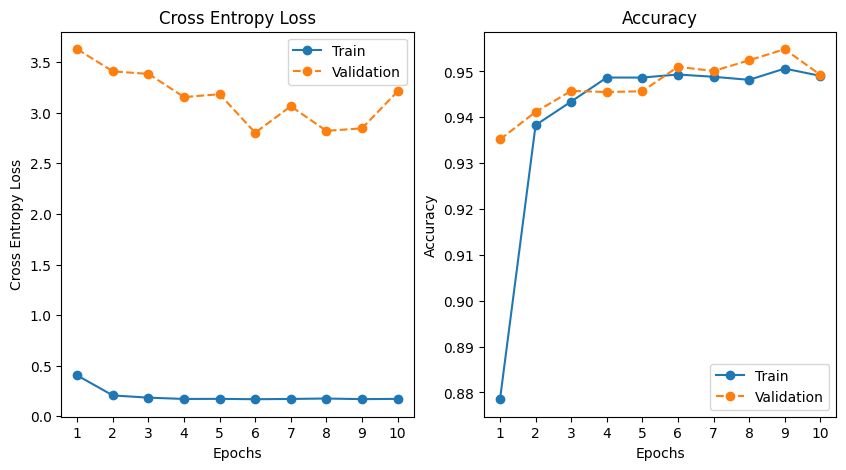

In [55]:
relu_actv = ActivationFunction(RELU, deriv_RELU, "RELU")
sig_actv = ActivationFunction(sigmoid, deriv_sigmoid, "Sigmoid")
soft_actv = ActivationFunction(softmax, None, "Softmax")

mse_eval = EvaluationFunction(mean_squared_error, deriv_mean_squared_error, "Mean Squared Error")
cross_eval = EvaluationFunction(cross_entropy_loss, deriv_cross_entropy_loss_with_softmax, "Cross Entropy Loss")
acc_eval = EvaluationFunction(accuracy, None, 'Accuracy')

decay_opt = DecayLearningOptimizer(lr=0.1, decay=0.95)
mom_opt = MomentumLearningOptimizer(lr=0.1, p=0.9)
adagrad_opt = AdaGradLearningOptimizer(lr=0.1)
rmsprop_opt = RMSPropLearningOptimizer(lr=0.1, beta=0.9)
adam_opt = AdamLearningOptimizer(lr=0.1, beta1=0.9, beta2=0.999)

he_init_strat = InitStrategy(he_init, name="HE Init")
xe_init_strat = InitStrategy(xe_init, name="XE Init")

bnorm_init_strat = InitStrategy(bnorm_init, name="BNORM Init")

simple_sequence = [
    DenseLayer(128, activation_func=relu_actv, init_strat=he_init_strat, resid_conn=True),
    DenseLayer(64, activation_func=relu_actv, init_strat=he_init_strat, resid_conn=True),
    BatchNormalization(init_strat=bnorm_init_strat),
    DenseLayer(10, activation_func=soft_actv, is_output=True, init_strat=he_init_strat, resid_conn=True),
]

complex_sequence = [
    DenseLayer(784, activation_func=relu_actv, init_strat=he_init_strat),
    DenseLayer(512, activation_func=relu_actv, init_strat=he_init_strat),
    BatchNormalization(init_strat=bnorm_init_strat),
    DenseLayer(256, activation_func=relu_actv, init_strat=he_init_strat),
    DenseLayer(128, activation_func=relu_actv, init_strat=he_init_strat),
    BatchNormalization(init_strat=bnorm_init_strat),
    DenseLayer(64, activation_func=relu_actv, init_strat=he_init_strat),
    DropoutLayer(0.3, scale=True),
    DenseLayer(10, activation_func=soft_actv, is_output=True, init_strat=he_init_strat),
]

nn = NeuralNetwork(simple_sequence, eval_func=acc_eval, loss_func=cross_eval, input_dim=x_train.shape, opt=adam_opt, use_l2=True, l2_reg=0.1)
nn.get_architecture()


n_epochs = 10
train_losses, train_accs, val_losses, val_accs = nn.fit(x_train, y_train, x_val, y_val, n_epochs, 256, True)

preds = nn.predict(x_test)
test_losses, test_accs = nn.evaluate(y_test, preds)

epochs = [i for i in range(1, n_epochs+1)]

fig = plt.figure(figsize=(10, 5))

fig.add_subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train", marker="o")
plt.plot(epochs, val_losses, label="Validation", marker="o", linestyle='--')
plt.xticks(epochs)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel(nn.loss_func.name)
plt.title(nn.loss_func.name)

fig.add_subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train', marker='o')
plt.plot(epochs, val_accs, label='Validation', marker='o', linestyle='--')
plt.xticks(epochs)
plt.legend()
plt.xlabel('Epochs')
plt.ylabel(nn.eval_func.name)
plt.title(nn.eval_func.name)

Text(0, 0.5, 'Proportion of dead neurons')

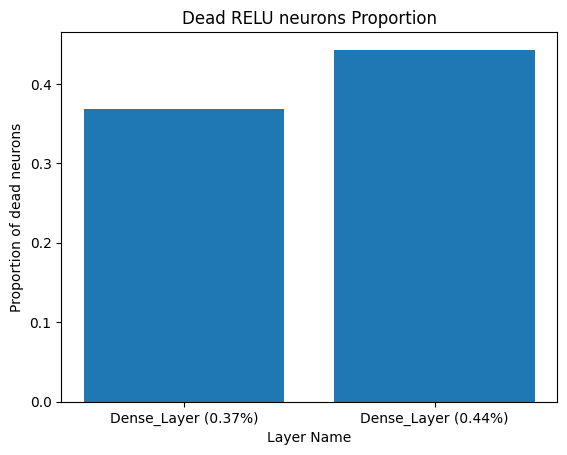

In [56]:
dead_relu_prop = []

for lyr in nn.layers:

  if lyr.is_trainable and not isinstance(lyr, BatchNormalization):

    if lyr.activation_func:

      if lyr.activation_func.name == "RELU":

        dead_relu_prop.append((np.sum(lyr.W > 0)/lyr.W.size, lyr.name))

values = [i[0] for i in dead_relu_prop]
names = [f"{dead_relu_prop[i][1]} ({dead_relu_prop[i][0]:.2f}%)" for i in range(len(dead_relu_prop))]

plt.bar(names, values)
plt.title("Dead RELU neurons Proportion")
plt.xlabel("Layer Name")
plt.ylabel("Proportion of dead neurons")

<Axes: >

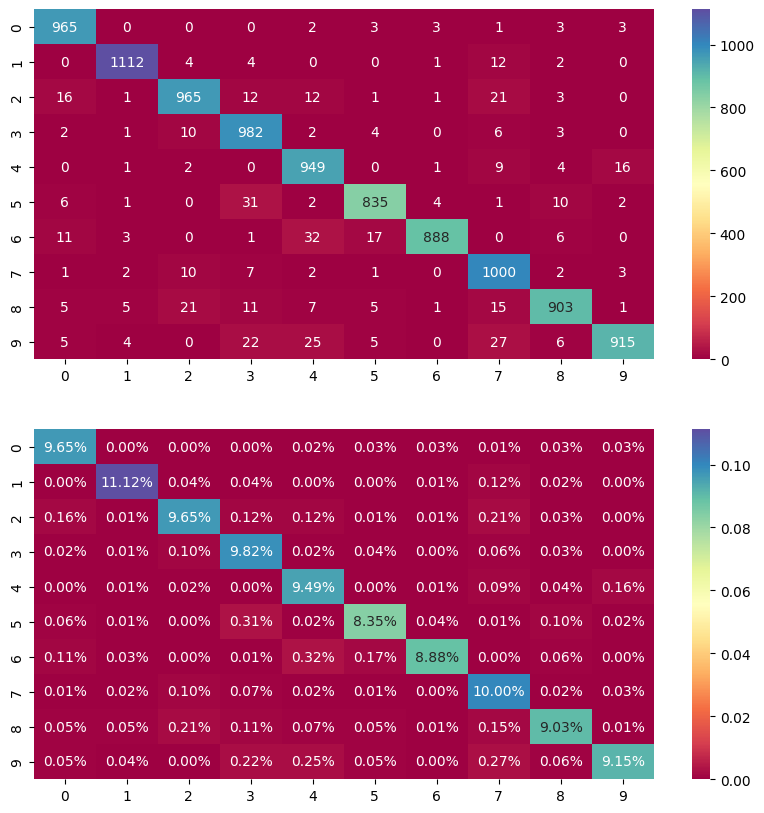

In [57]:
import seaborn as sns

preds = nn.predict(x_test)
preds = np.apply_along_axis(lambda col: np.argmax(col), axis=0, arr=preds)
y_test_tmp = np.apply_along_axis(lambda col: np.argmax(col), axis=0, arr=y_test)

classes = [i for i in range(10)]

confusion_matrix = np.zeros((10, 10), dtype='int64')

for i in range(preds.shape[0]):
  confusion_matrix[y_test_tmp[i], preds[i]] += 1

fig = plt.figure(figsize=(10, 10))

fig.add_subplot(2, 1, 1)
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Spectral")

fig.add_subplot(2, 1, 2)
sns.heatmap(confusion_matrix / preds.size, annot=True, fmt=".2%", cmap="Spectral")

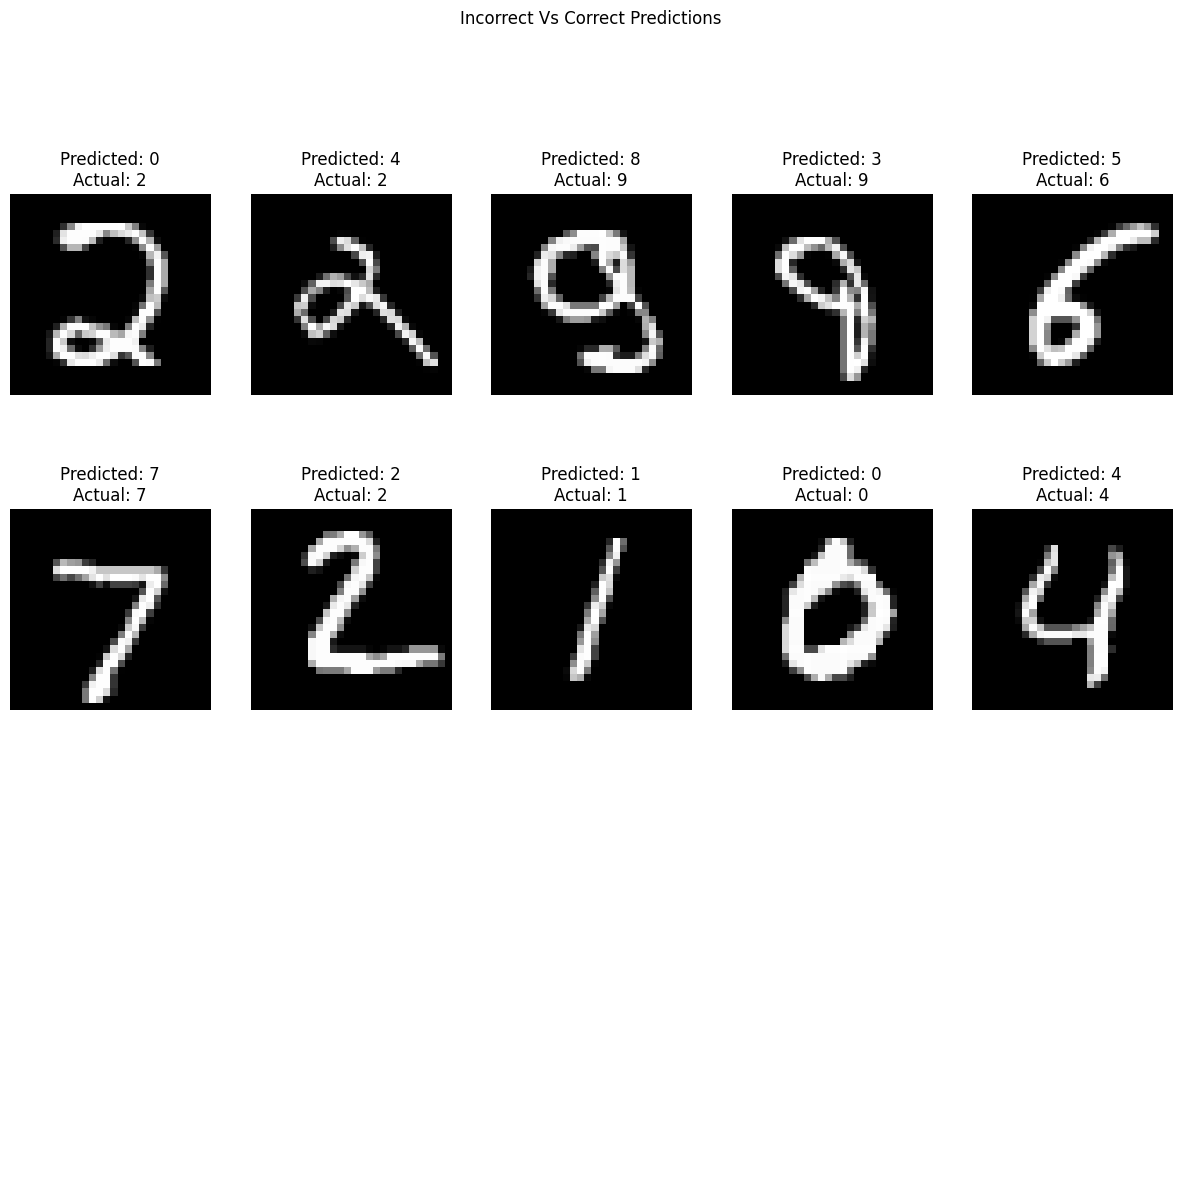

In [58]:
fig = plt.figure(figsize=(15, 15))
plt.title("Incorrect Vs Correct Predictions")
plt.axis("off")

for i in range(5):

  fig.add_subplot(1, 5, i+1)
  plt.imshow(np.reshape(x_test[:, i], (28, 28)), cmap="gray")
  plt.title(f"Predicted: {preds[i]}\nActual: {y_test_tmp[i]}")
  plt.axis("off")

incorrect_preds = np.where(preds != y_test_tmp)[0]
for i in range(5):

  ind = incorrect_preds[i]

  fig.add_subplot(2, 5, i+1)
  plt.imshow(np.reshape(x_test[:, ind], (28,28)), cmap="grey")
  plt.title(f"Predicted: {preds[ind]}\nActual: {y_test_tmp[ind]}")
  plt.axis("off")

plt.show()

In [59]:
# batch_sizes = [2**i for i in range(11)]

# val_losses = []
# val_accs = []



# for batch_size in batch_sizes:
#   temp_nn = NeuralNetwork(simple_sequence, input_dim=x_train.shape, opt=decay_opt, loss_func=cross_eval, eval_func=acc_eval)
#   train_loss, train_acc, val_loss, val_acc = temp_nn.fit(x_train, y_train, x_val, y_val, 5, batch_size, use_val=True)
#   test_loss, test_acc = temp_nn.evaluate(y_test, temp_nn.predict(x_test))
#   val_losses.append(val_loss)
#   val_accs.append(val_acc)

# fig = plt.figure(figsize=(15, 5))

# fig.add_subplot(1, 2, 1)
# plt.title("Validation Loss")
# for i in range(len(batch_sizes)):
#   plt.plot([i+1 for i in range(5)], val_losses[i], label=f"Batch Size: {batch_sizes[i]}", marker="o")
# plt.ylabel(temp_nn.loss_func.name)
# plt.xlabel("Epochs")
# plt.legend()

# fig.add_subplot(1, 2, 2)
# plt.title("Accurac
# for i in range(len(batch_sizes)):
#   plt.plot([i+1 for i in range(5)], val_accs[i], label=f"Batch Size: {batch_sizes[i]}", marker="o")
# plt.ylabel(temp_nn.eval_func.name)
# plt.xlabel("Epochs")
# plt.legend()




In [60]:
# batch_sizes = [16, 32, 64, 128]

# lrs = [0.001, 0.01, 0.1, 1]

# losses = np.zeros((4, 4))

# for i in range(4):

#   for j in range(4):

#     batch_size, lr = batch_sizes[i], lrs[j]

#     decay_opt = DecayLearningOptimizer(start_lr=lr, decay=0.95)

#     temp_nn = NeuralNetwork(simple_sequence, input_dim=x_train.shape, opt=decay_opt, loss_func=cross_eval, eval_func=acc_eval)

#     _, _, = temp_nn.fit(x_train, y_train, 5, batch_size)

#     test_loss, test_acc = temp_nn.evaluate(y_test, temp_nn.predict(x_test))

#     losses[i, j] = test_loss

#     print(f"Batch Size: {batch_size}, Learning Rate: {lr}, Test Loss: {test_loss}")

# sns.heatmap(losses, cmap="coolwarm", annot=True, fmt=".2f", xticklabels=lrs, yticklabels=batch_sizes)
# plt.title("Test Loss")
# plt.xlabel("Learning Rate")
# plt.ylabel("Batch Size")



 40%|████      | 2/5 [00:09<00:15,  5.01s/it]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
100%|██████████| 5/5 [00:23<00:00,  4.79s/it]


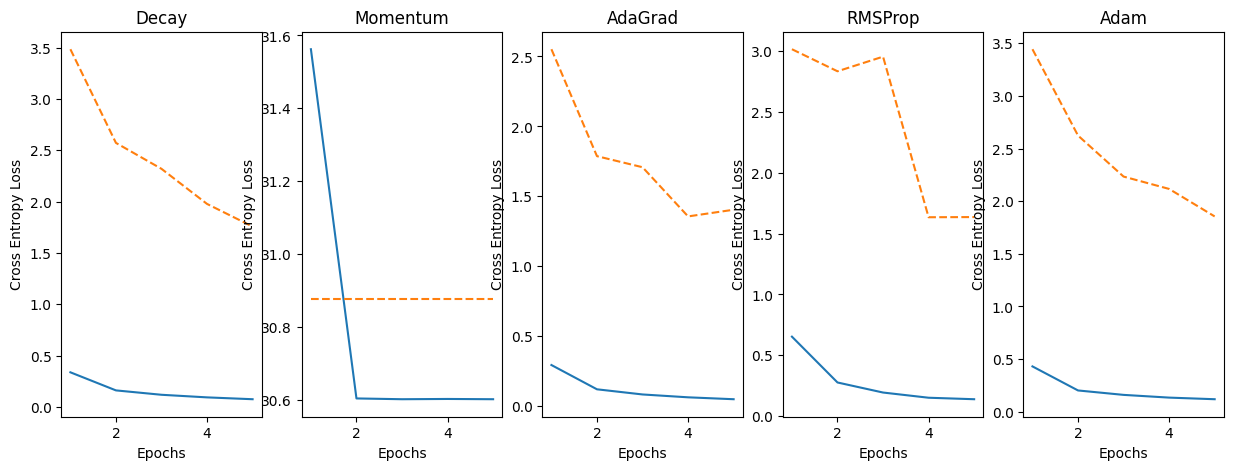

In [61]:
fig = plt.figure(figsize=(15, 5))

n_epochs = 5

for i, opt in enumerate([decay_opt, mom_opt, adagrad_opt, rmsprop_opt, adam_opt]):

  temp_nn = NeuralNetwork(simple_sequence, input_dim=x_train.shape, opt=opt, loss_func=cross_eval, eval_func=acc_eval)

  train_losses, train_accs, val_losses, val_accs = temp_nn.fit(x_train, y_train, x_val, y_val, n_epochs, 256, use_val=True)

  fig.add_subplot(1, 5, i+1)

  plt.plot([i+1 for i in range(n_epochs)], train_losses)
  plt.plot([i+1 for i in range(n_epochs)], val_losses, linestyle='--')
  plt.title(opt.name)
  plt.xlabel("Epochs")
  plt.ylabel(temp_nn.loss_func.name)

plt.show()